# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The AI Impact On Health Dataset](https://www.kaggle.com/datasets/gauravjhaeigenvector/ai-impact-on-health)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('AI_Impact_on_Health_Dataset_5000_Enhanced.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Participant_ID,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,...,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Category,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
0,1,56,56-65,Female,No,22.2,Normal,Fitness Tracker,8,Medium,...,17,68,69,1,1.47,Improved,0.11,9,High,Low
1,2,69,66-79,Male,No,24.8,Normal,Fitness Tracker,8,Medium,...,19,51,63,12,23.53,Highly Improved,1.33,7,Medium,Low
2,3,46,46-55,Female,No,23.1,Normal,Mental Health App,8,Medium,...,12,57,72,15,26.32,Highly Improved,1.67,5,Medium,Low
3,4,32,26-35,Female,Yes,24.9,Normal,Fitness Tracker,16,High,...,17,83,99,16,19.28,Highly Improved,0.94,1,Low,Medium
4,5,60,56-65,Male,No,30.4,Obese,Fitness Tracker,11,Medium,...,12,41,39,-2,-4.88,Declined,-0.17,9,High,Medium


## last Five row

In [4]:
df.tail()

,Participant_ID,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,...,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Category,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
4995,4996,42,36-45,Female,Yes,20.0,Normal,Fitness Tracker,19,High,...,19,57,58,1,1.75,Improved,0.05,10,High,Medium
4996,4997,39,36-45,Female,Yes,22.7,Normal,Diagnostic Assistant,16,High,...,20,52,57,5,9.62,Improved,0.29,5,Medium,Medium
4997,4998,48,46-55,Female,No,26.8,Overweight,Mental Health App,13,Medium,...,25,61,71,10,16.39,Improved,0.71,3,Low,Low
4998,4999,34,26-35,Female,Yes,27.9,Overweight,Telemedicine,13,Medium,...,15,53,72,19,35.85,Highly Improved,1.36,2,Low,Medium
4999,5000,72,66-79,Male,No,22.0,Normal,Diagnostic Assistant,2,Low,...,6,50,56,6,12.00,Improved,2.00,6,Medium,Low


## Shape of our dataset

In [5]:
df.shape

(5000, 22)

## List out all columns

In [6]:
df.columns

Index(['Participant_ID', 'Age', 'Age_Group', 'Gender', 'Chronic_Condition',
       'BMI', 'BMI_Category', 'AI_Tool_Type',
       'AI_Health_App_Usage_Hours_Per_Week', 'AI_Usage_Level',
       'Exercise_Hours_Per_Week', 'Exercise_Level',
       'Total_Engagement_Hours_Per_Week', 'Health_Score_Before_AI',
       'Health_Score_After_AI', 'Improvement', 'Improvement_Percentage',
       'Improvement_Category', 'Improvement_Per_AI_Hour', 'Satisfaction_Score',
       'Satisfaction_Level', 'Risk_Category'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Participant_ID                          int64
Age                                     int64
Age_Group                              object
Gender                                 object
Chronic_Condition                      object
BMI                                   float64
BMI_Category                           object
AI_Tool_Type                           object
AI_Health_App_Usage_Hours_Per_Week      int64
AI_Usage_Level                         object
Exercise_Hours_Per_Week                 int64
Exercise_Level                         object
Total_Engagement_Hours_Per_Week         int64
Health_Score_Before_AI                  int64
Health_Score_After_AI                   int64
Improvement                             int64
Improvement_Percentage                float64
Improvement_Category                   object
Improvement_Per_AI_Hour               float64
Satisfaction_Score                      int64
Satisfaction_Level                     object
Risk_Category                     

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Participant_ID                      5000 non-null   int64  
 1   Age                                 5000 non-null   int64  
 2   Age_Group                           5000 non-null   object 
 3   Gender                              5000 non-null   object 
 4   Chronic_Condition                   5000 non-null   object 
 5   BMI                                 5000 non-null   float64
 6   BMI_Category                        5000 non-null   object 
 7   AI_Tool_Type                        5000 non-null   object 
 8   AI_Health_App_Usage_Hours_Per_Week  5000 non-null   int64  
 9   AI_Usage_Level                      5000 non-null   object 
 10  Exercise_Hours_Per_Week             5000 non-null   int64  
 11  Exercise_Level                      5000 no

## Check Null Value

In [9]:
df.isnull().sum()

Participant_ID                        0
Age                                   0
Age_Group                             0
Gender                                0
Chronic_Condition                     0
BMI                                   0
BMI_Category                          0
AI_Tool_Type                          0
AI_Health_App_Usage_Hours_Per_Week    0
AI_Usage_Level                        0
Exercise_Hours_Per_Week               0
Exercise_Level                        0
Total_Engagement_Hours_Per_Week       0
Health_Score_Before_AI                0
Health_Score_After_AI                 0
Improvement                           0
Improvement_Percentage                0
Improvement_Category                  0
Improvement_Per_AI_Hour               0
Satisfaction_Score                    0
Satisfaction_Level                    0
Risk_Category                         0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Participant_ID,Age,BMI,AI_Health_App_Usage_Hours_Per_Week,Exercise_Hours_Per_Week,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Per_AI_Hour,Satisfaction_Score
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,2500.500000,48.805600,25.01756,10.235600,7.047000,17.282600,64.432200,71.734000,7.30180,12.097002,1.210306,5.512000
std,1443.520003,17.906991,3.98090,6.016389,4.299033,7.424673,14.563015,16.016446,7.35823,13.010823,2.471517,2.856692
min,1.000000,18.000000,10.60000,0.000000,0.000000,0.000000,40.000000,35.000000,-5.00000,-12.500000,-5.000000,1.000000
25%,1250.750000,34.000000,22.40000,5.000000,3.000000,12.000000,52.000000,59.000000,1.00000,1.450000,0.080000,3.000000
50%,2500.500000,49.000000,25.05000,10.500000,7.000000,17.000000,64.000000,72.000000,7.00000,11.410000,0.670000,6.000000
75%,3750.250000,64.000000,27.70000,15.000000,11.000000,23.000000,77.000000,84.000000,13.00000,21.280000,1.330000,8.000000
max,5000.000000,79.000000,38.60000,20.000000,14.000000,34.000000,89.000000,100.000000,20.00000,50.000000,20.000000,10.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

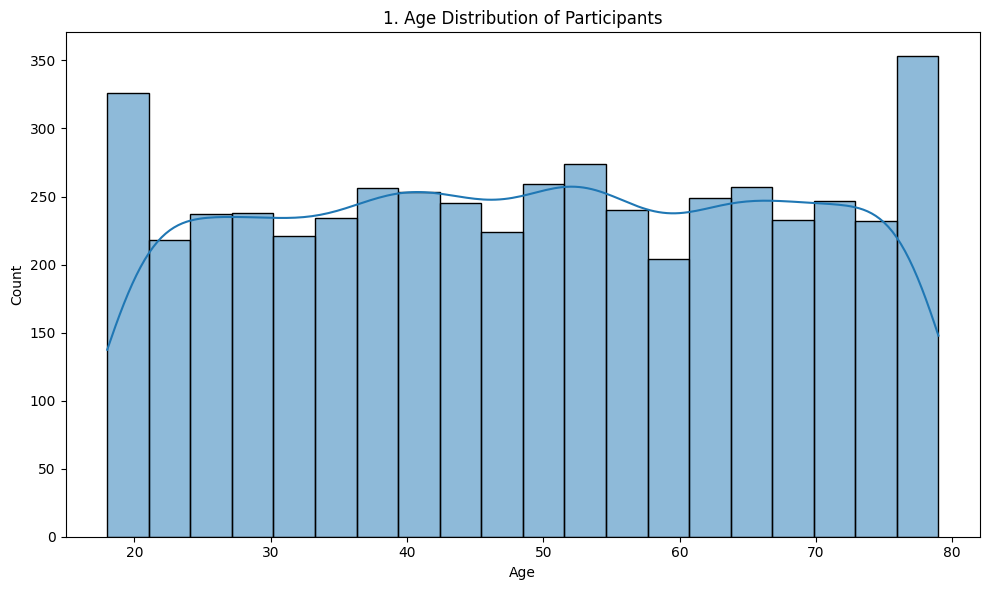

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title(f'{plot_no}. Age Distribution of Participants')
show_fig()
plot_no += 1

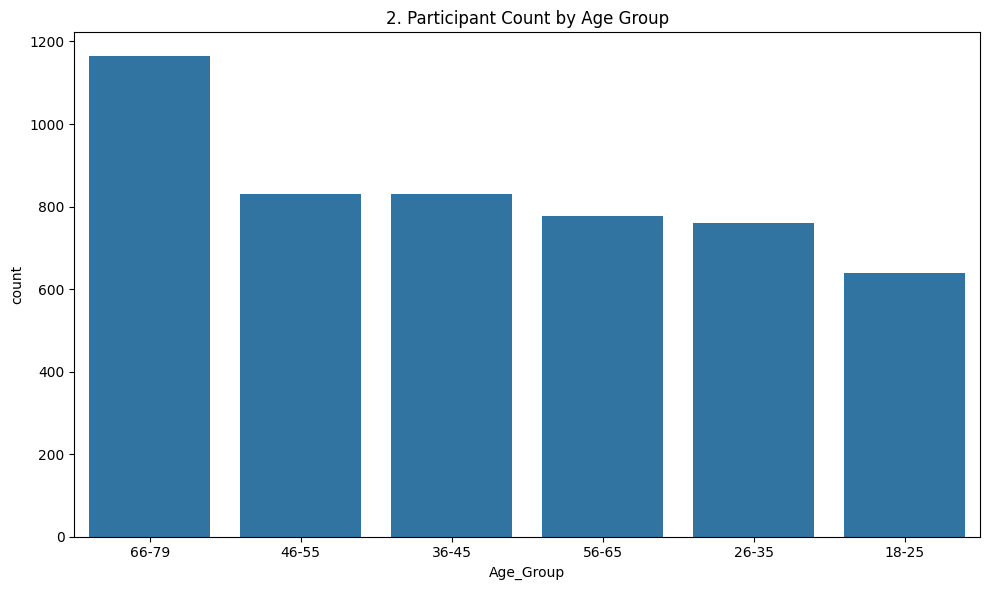

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Age_Group', order=df['Age_Group'].value_counts().index)
plt.title(f'{plot_no}. Participant Count by Age Group')
show_fig()
plot_no += 1

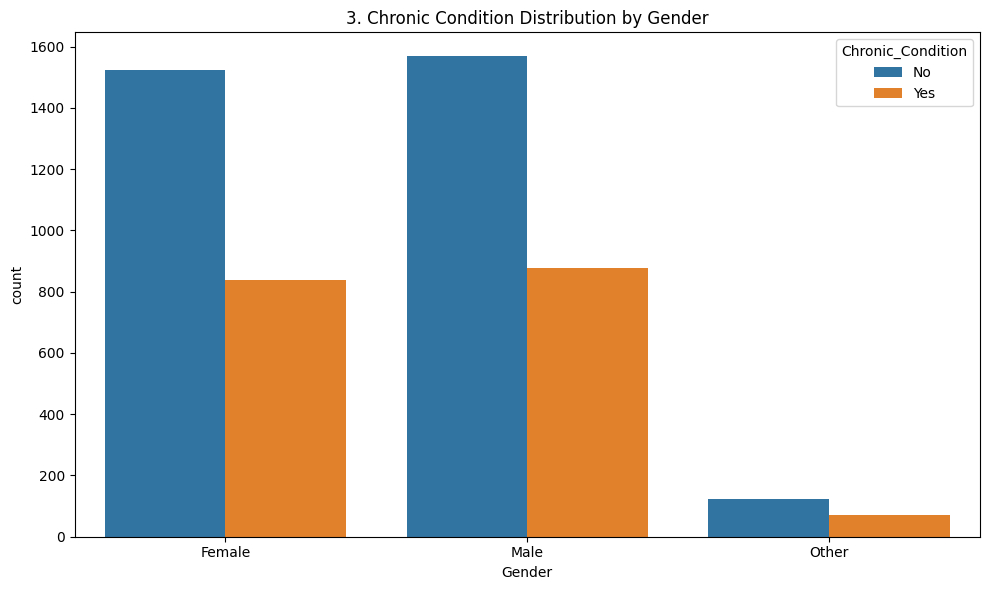

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Gender', hue='Chronic_Condition')
plt.title(f'{plot_no}. Chronic Condition Distribution by Gender')
show_fig()
plot_no += 1

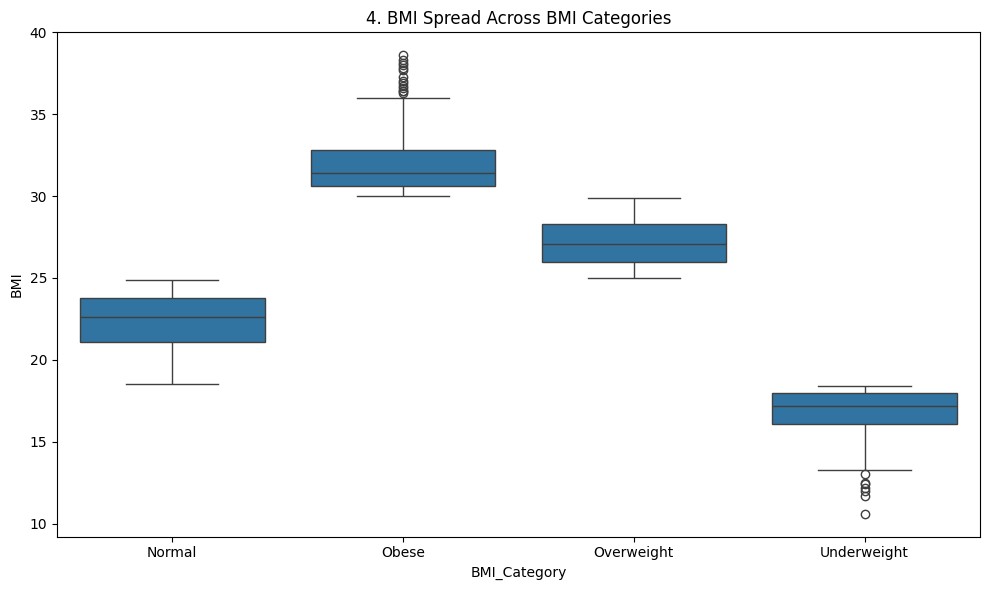

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='BMI_Category', y='BMI')
plt.title(f'{plot_no}. BMI Spread Across BMI Categories')
show_fig()
plot_no += 1

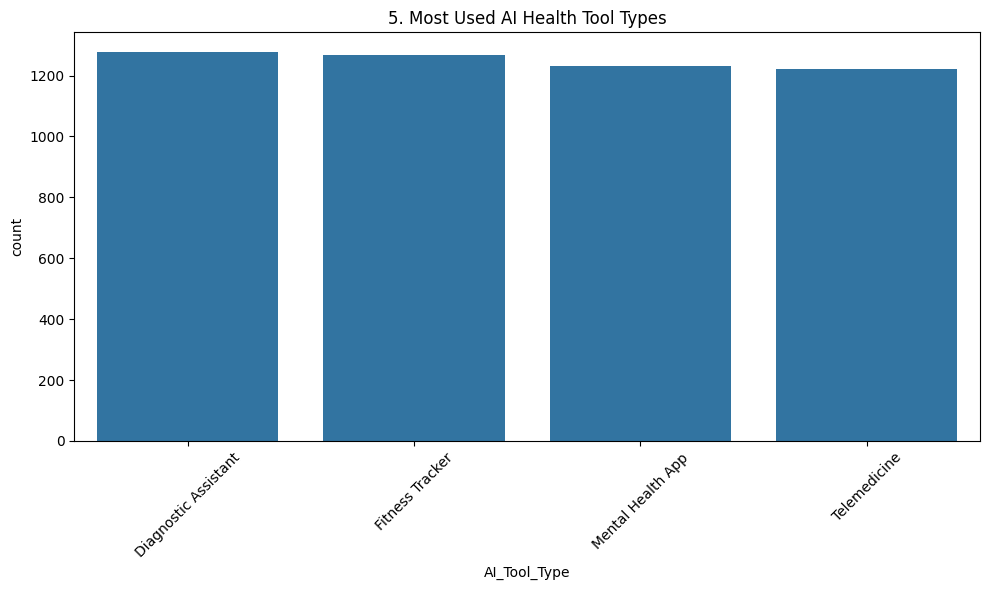

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='AI_Tool_Type', order=df['AI_Tool_Type'].value_counts().index)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Most Used AI Health Tool Types')
show_fig()
plot_no += 1

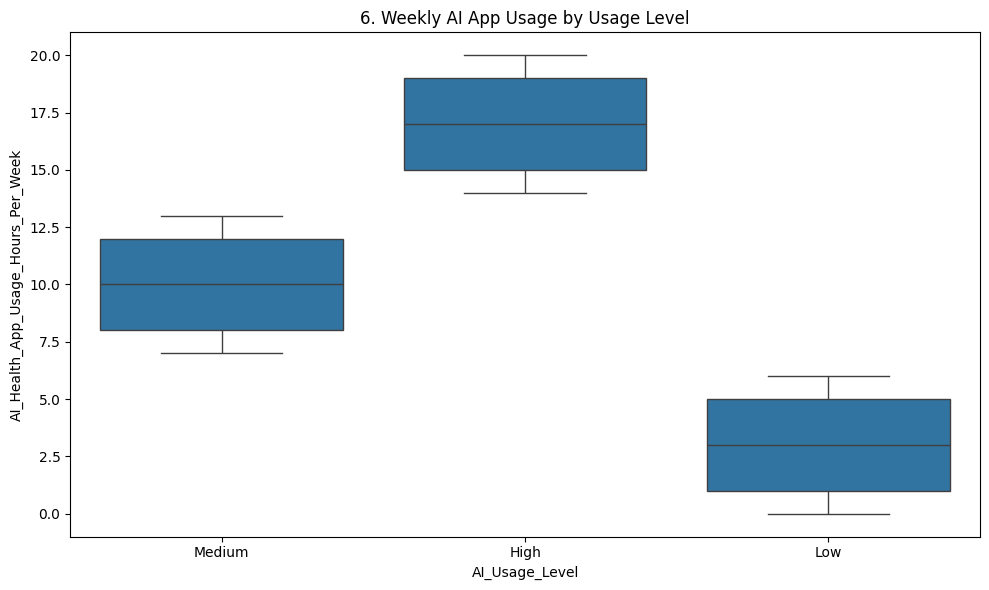

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='AI_Usage_Level', y='AI_Health_App_Usage_Hours_Per_Week')
plt.title(f'{plot_no}. Weekly AI App Usage by Usage Level')
show_fig()
plot_no += 1

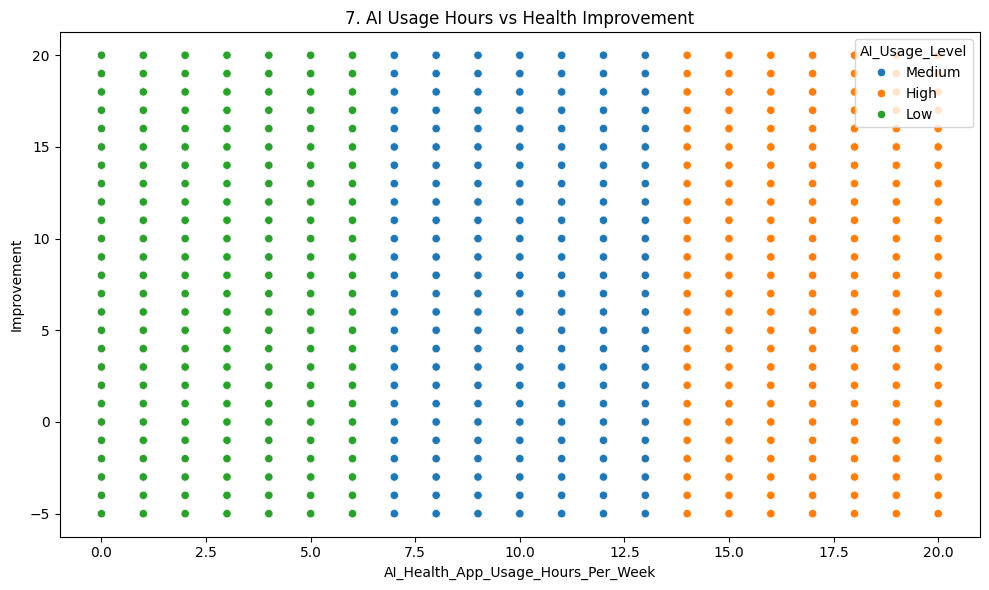

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='AI_Health_App_Usage_Hours_Per_Week', y='Improvement', hue='AI_Usage_Level')
plt.title(f'{plot_no}. AI Usage Hours vs Health Improvement')
show_fig()
plot_no += 1

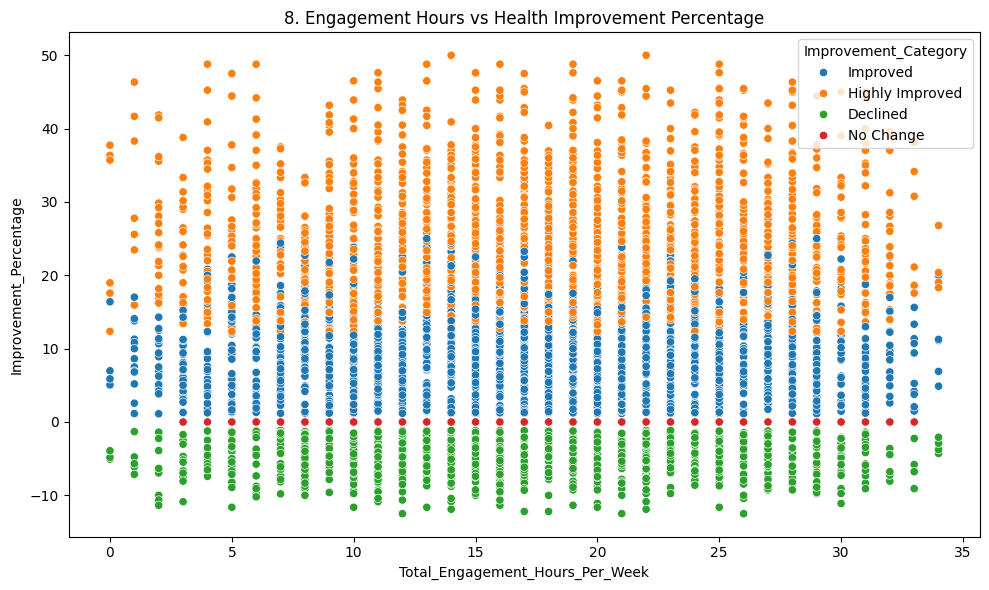

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Total_Engagement_Hours_Per_Week', y='Improvement_Percentage', hue='Improvement_Category')
plt.title(f'{plot_no}. Engagement Hours vs Health Improvement Percentage')
show_fig()
plot_no += 1

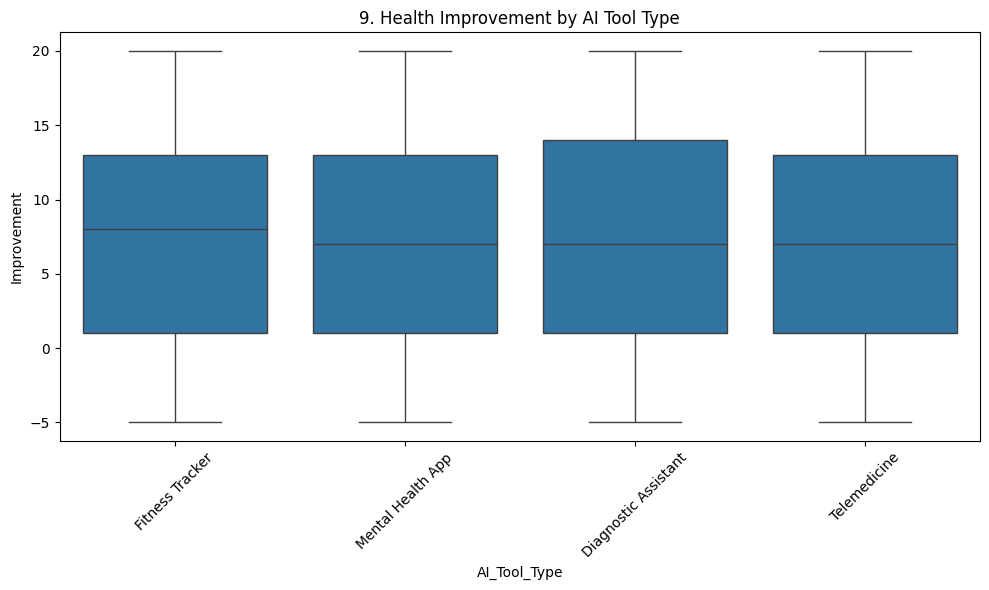

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='AI_Tool_Type', y='Improvement')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Health Improvement by AI Tool Type')
show_fig()
plot_no += 1

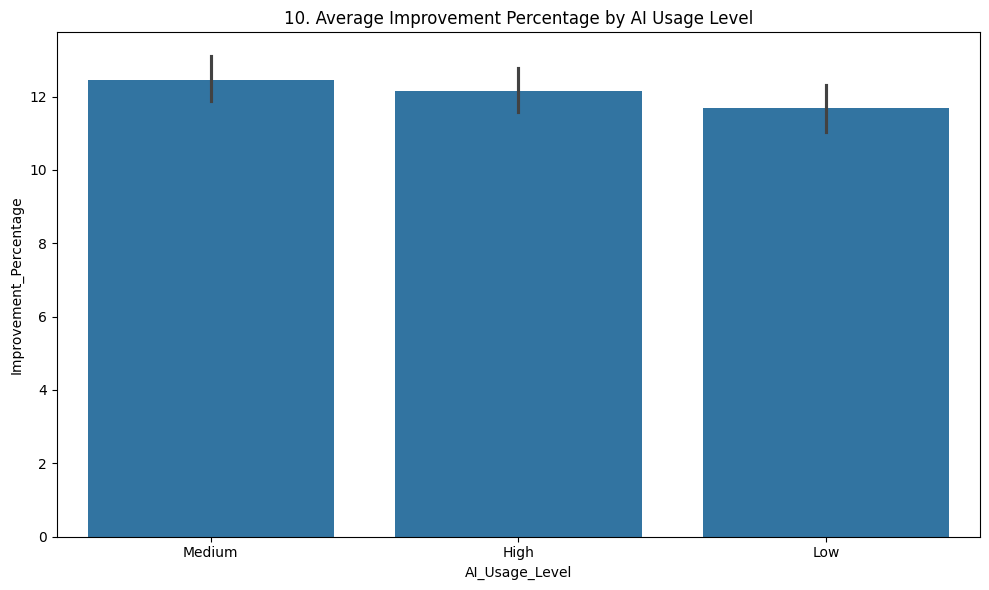

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='AI_Usage_Level', y='Improvement_Percentage', estimator='mean')
plt.title(f'{plot_no}. Average Improvement Percentage by AI Usage Level')
show_fig()
plot_no += 1

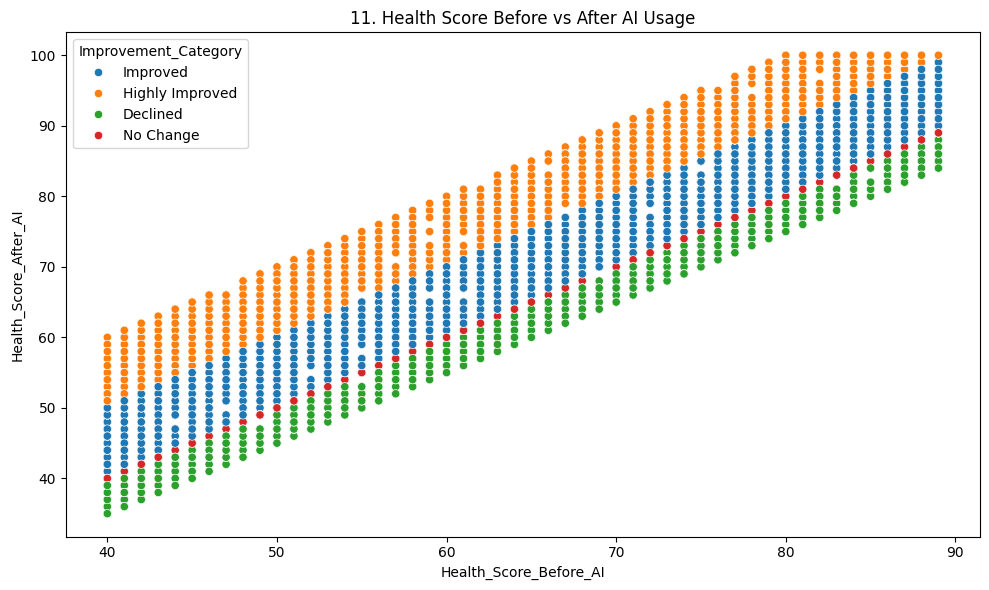

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Health_Score_Before_AI', y='Health_Score_After_AI', hue='Improvement_Category')
plt.title(f'{plot_no}. Health Score Before vs After AI Usage')
show_fig()
plot_no += 1

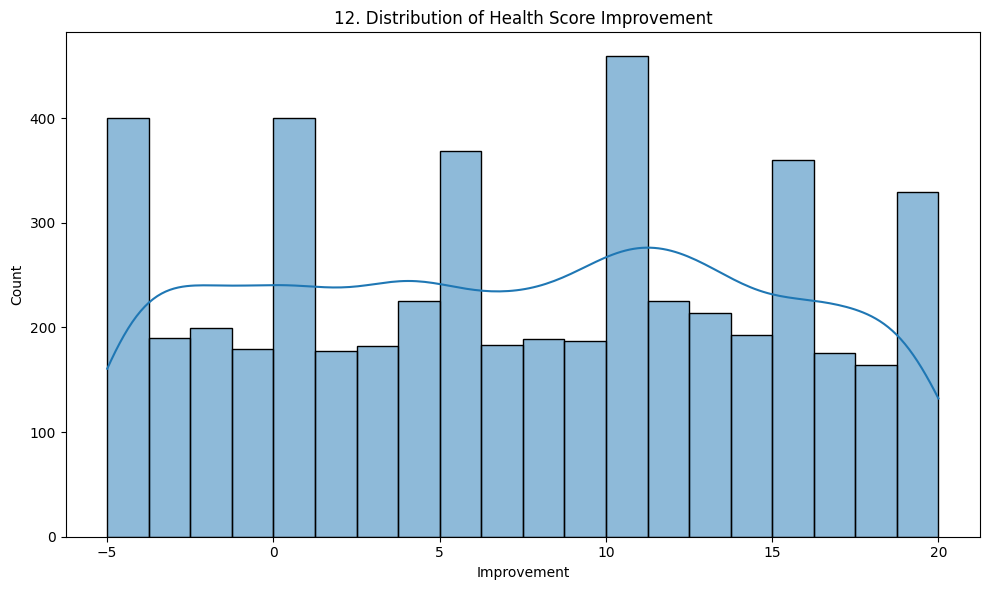

In [24]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Improvement'], bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Health Score Improvement')
show_fig()
plot_no += 1

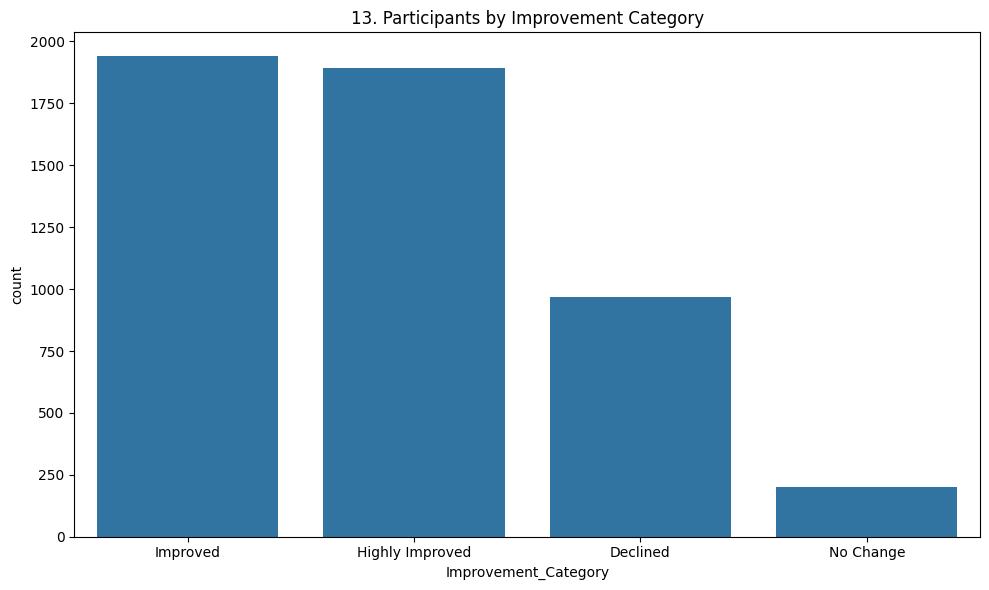

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Improvement_Category', order=df['Improvement_Category'].value_counts().index)
plt.title(f'{plot_no}. Participants by Improvement Category')
show_fig()
plot_no += 1

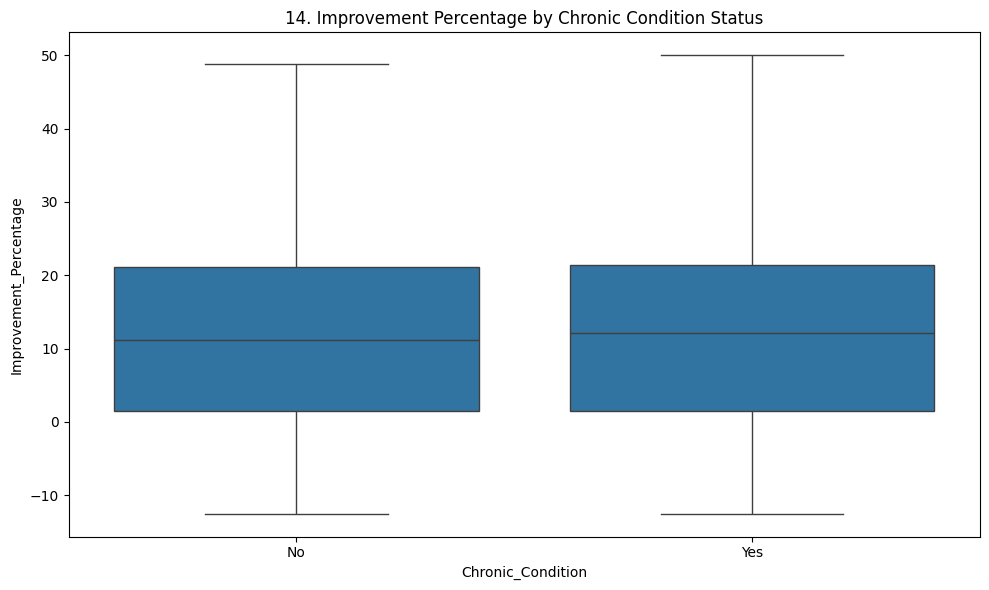

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Chronic_Condition', y='Improvement_Percentage')
plt.title(f'{plot_no}. Improvement Percentage by Chronic Condition Status')
show_fig()
plot_no += 1

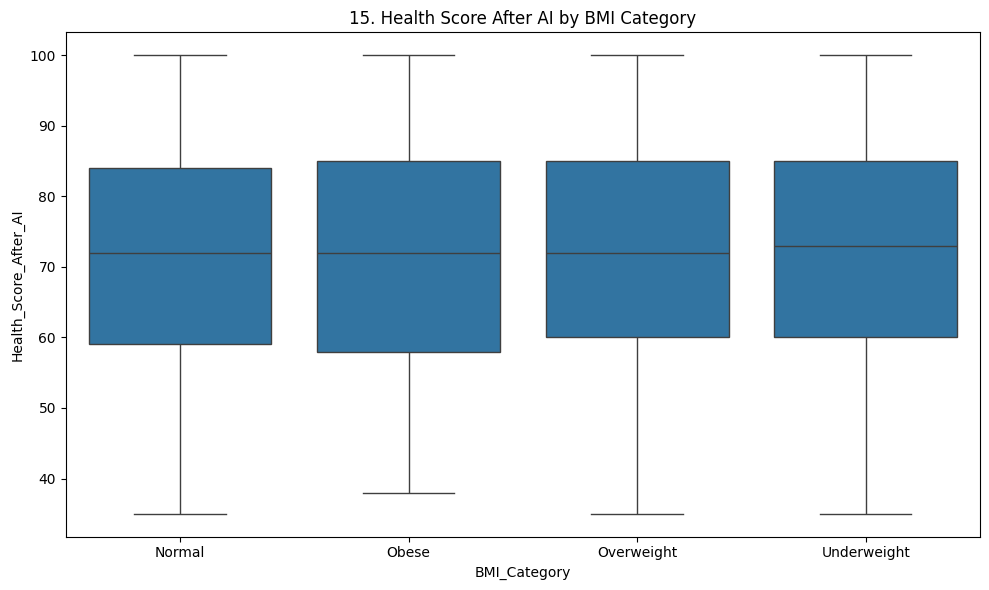

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='BMI_Category', y='Health_Score_After_AI')
plt.title(f'{plot_no}. Health Score After AI by BMI Category')
show_fig()
plot_no += 1

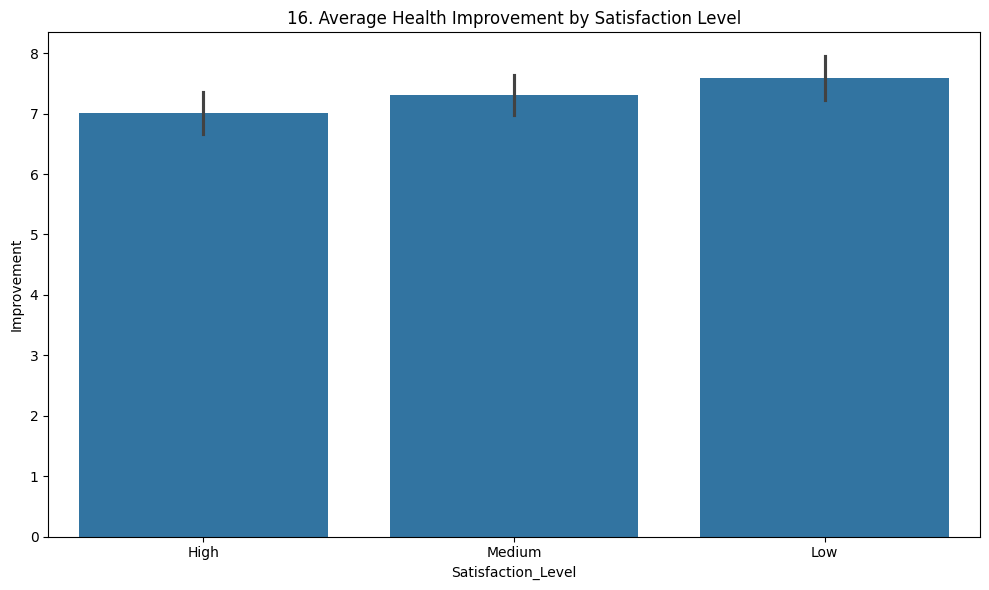

In [28]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Satisfaction_Level', y='Improvement', estimator='mean')
plt.title(f'{plot_no}. Average Health Improvement by Satisfaction Level')
show_fig()
plot_no += 1

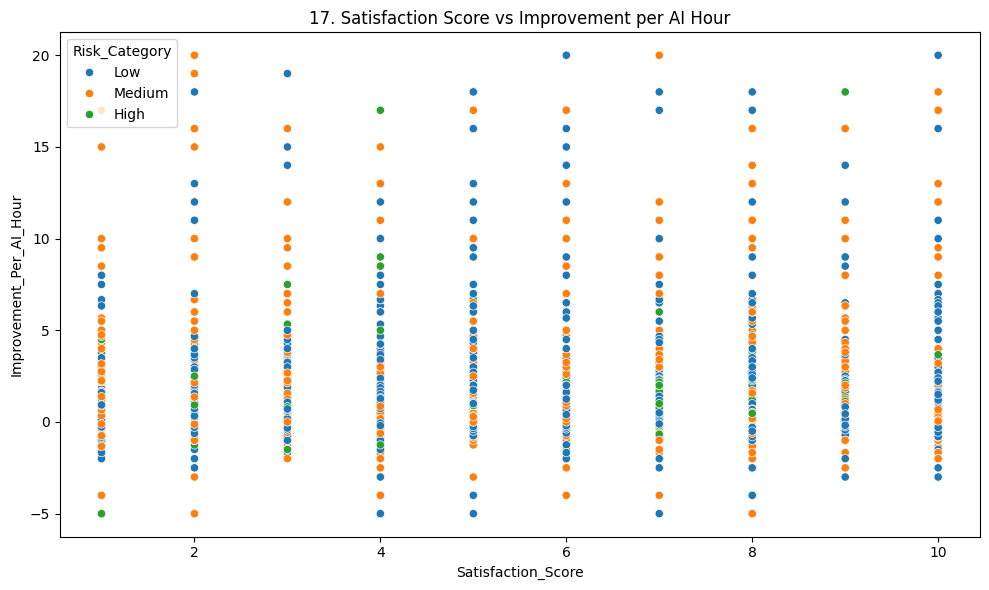

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Satisfaction_Score', y='Improvement_Per_AI_Hour', hue='Risk_Category')
plt.title(f'{plot_no}. Satisfaction Score vs Improvement per AI Hour')
show_fig()
plot_no += 1

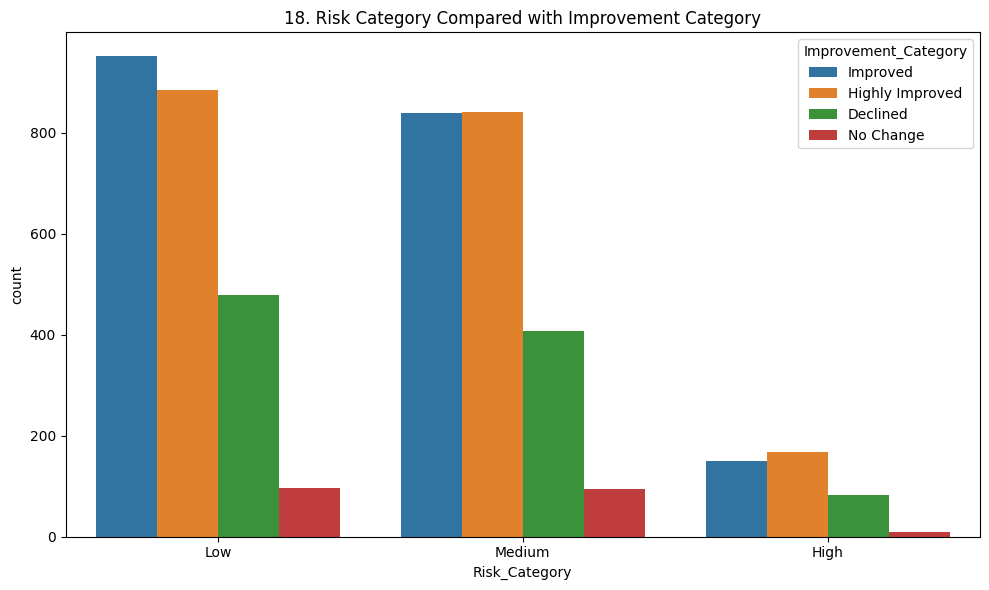

In [30]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Risk_Category', hue='Improvement_Category')
plt.title(f'{plot_no}. Risk Category Compared with Improvement Category')
show_fig()
plot_no += 1

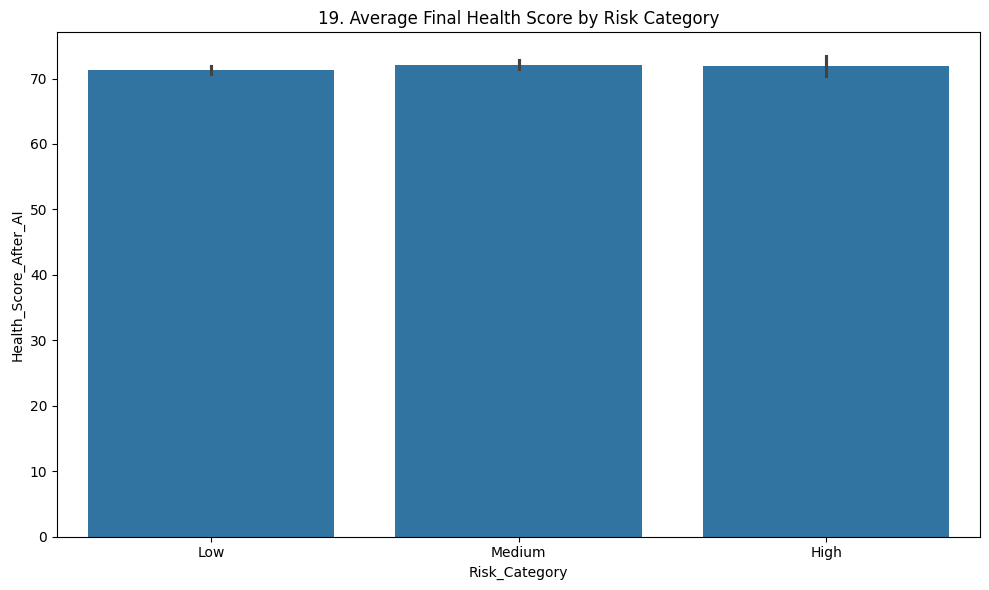

In [31]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Risk_Category', y='Health_Score_After_AI', estimator='mean')
plt.title(f'{plot_no}. Average Final Health Score by Risk Category')
show_fig()
plot_no += 1

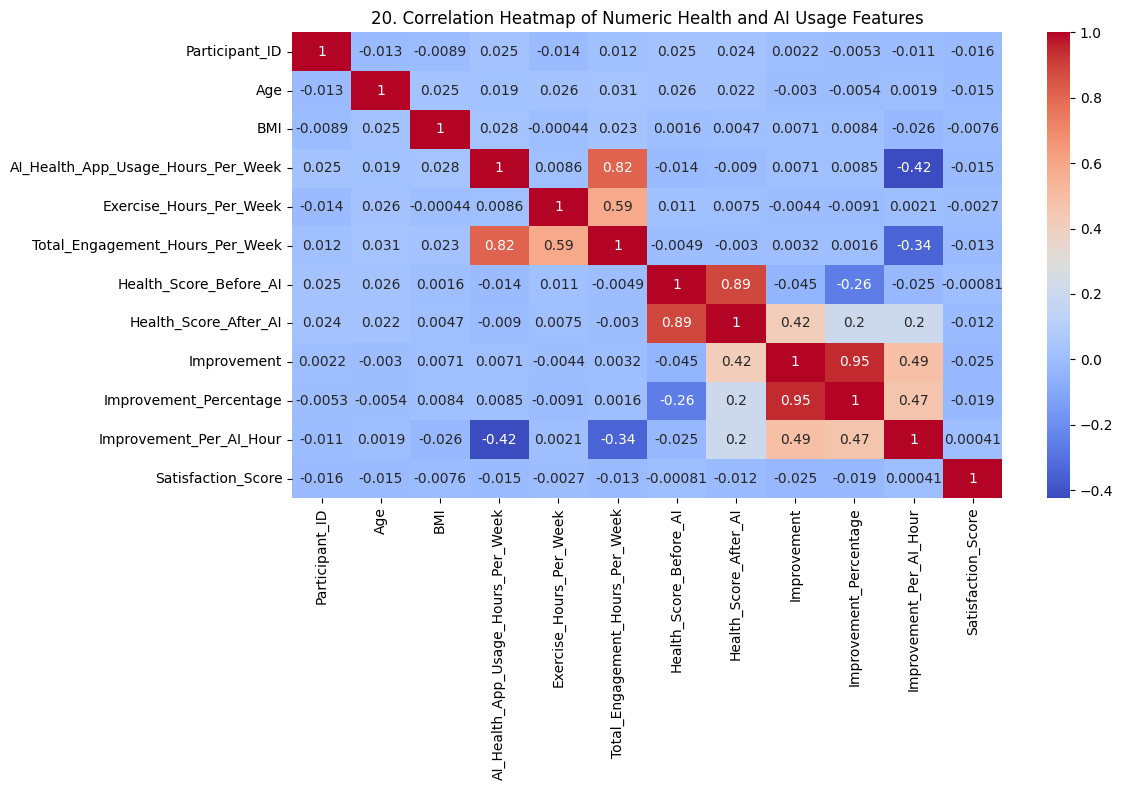

In [32]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numeric Health and AI Usage Features')
show_fig()
plot_no += 1

In [33]:
corr

,Participant_ID,Age,BMI,AI_Health_App_Usage_Hours_Per_Week,Exercise_Hours_Per_Week,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Per_AI_Hour,Satisfaction_Score
Participant_ID,1.000000,-0.012667,-0.008850,0.025026,-0.013811,0.012282,0.024770,0.023553,0.002244,-0.005348,-0.010541,-0.015721
Age,-0.012667,1.000000,0.025317,0.019221,0.026481,0.030908,0.026113,0.022350,-0.003033,-0.005363,0.001937,-0.015139
BMI,-0.008850,0.025317,1.000000,0.028288,-0.000435,0.022671,0.001590,0.004715,0.007117,0.008370,-0.025510,-0.007646
AI_Health_App_Usage_Hours_Per_Week,0.025026,0.019221,0.028288,1.000000,0.008644,0.815329,-0.013528,-0.009034,0.007110,0.008504,-0.423521,-0.014667
Exercise_Hours_Per_Week,-0.013811,0.026481,-0.000435,0.008644,1.000000,0.586024,0.010507,0.007538,-0.004388,-0.009131,0.002080,-0.002709
Total_Engagement_Hours_Per_Week,0.012282,0.030908,0.022671,0.815329,0.586024,1.000000,-0.004878,-0.002956,0.003221,0.001604,-0.341985,-0.013453
Health_Score_Before_AI,0.024770,0.026113,0.001590,-0.013528,0.010507,-0.004878,1.000000,0.888464,-0.045253,-0.260013,-0.024507,-0.000810
Health_Score_After_AI,0.023553,0.022350,0.004715,-0.009034,0.007538,-0.002956,0.888464,1.000000,0.418271,0.199809,0.204143,-0.012412
Improvement,0.002244,-0.003033,0.007117,0.007110,-0.004388,0.003221,-0.045253,0.418271,1.000000,0.949522,0.492856,-0.025415
Improvement_Percentage,-0.005348,-0.005363,0.008370,0.008504,-0.009131,0.001604,-0.260013,0.199809,0.949522,1.000000,0.467438,-0.018672


# Model Training

## Copy dataframe

In [34]:
data = df.copy()

## Drop ID column because it is not useful for prediction

In [35]:
data = data.drop(columns=['Participant_ID'], errors='ignore')

## Select target column

In [36]:
target = 'Improvement_Category'

## Remove rows with missing target values

In [37]:
data = data.dropna(subset=[target])

## Separate input features and target

In [38]:
X = data.drop(columns=[target])
y = data[target]

## Encode categorical input columns

In [39]:
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

## Fill missing numeric values

In [40]:
X = X.fillna(X.median(numeric_only=True))

## Encode target column

In [41]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y.astype(str))

## Split data into train and test sets

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Scale features for Logistic Regression

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Create supervised classification model

In [44]:
model = LogisticRegression(max_iter=2000)

## Train model

In [45]:
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


## Predict test data

In [46]:
y_pred = model.predict(X_test_scaled)

## Print accuracy score

In [47]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.99


## Print classification report

In [48]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))


Classification Report:
                 precision    recall  f1-score   support

       Declined       0.99      1.00      1.00       194
Highly Improved       1.00      1.00      1.00       378
       Improved       0.98      1.00      0.99       388
      No Change       1.00      0.75      0.86        40

       accuracy                           0.99      1000
      macro avg       0.99      0.94      0.96      1000
   weighted avg       0.99      0.99      0.99      1000



## Plot confusion matrix

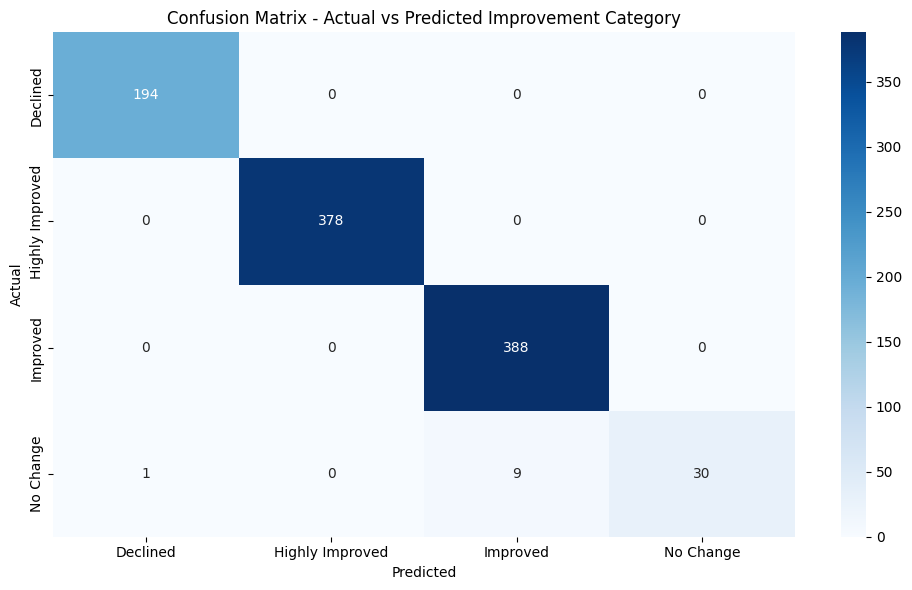

In [49]:
cm = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Actual vs Predicted Improvement Category")
plt.tight_layout()
plt.show()